# Feature-Based Baseline Model: Logistic Regression

In this notebook, I build a classical feature-based baseline for named entity recognition using logistic regression. The idea is simple, each token is classified independently, but I still provide the model with a small amount of local context through hand crafted features.

This baseline is important for the project because it gives me a strong non-neural comparison point before I move to the BiLSTM model. It also helps me test whether visible cues such as capital letters, suffixes, POS tags, and neighbouring words are already enough to capture a large part of the NER task.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **1. Load Dataset**

The dataset stores one token per line with four columns: 'word', 'POS', 'chunk', and 'NER tag'. Blank lines separate sentences. I load each sentence as a list of token dictionaries so I can use richer features later. Also, I keep the dataset in a different format compared to the 'data exploration notebook' because I need POS and chunk information as input features for the feature-based model.

In [3]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [4]:
from src.load_dataset import load_dataset_lr

train_sentences = load_dataset_lr("../data/raw/train.txt")
valid_sentences = load_dataset_lr("../data/raw/valid.txt")
test_sentences = load_dataset_lr("../data/raw/test.txt")

print(f"Train sentences: {len(train_sentences): }")
print(f"Valid sentences: {len(valid_sentences): }")
print(f"Test sentences:  {len(test_sentences): }")

Train sentences:  14041
Valid sentences:  3250
Test sentences:   3453


In [5]:
train_sentences[0]

[{'word': 'EU', 'pos': 'NNP', 'chunk': 'B-NP', 'ner': 'B-ORG'},
 {'word': 'rejects', 'pos': 'VBZ', 'chunk': 'B-VP', 'ner': 'O'},
 {'word': 'German', 'pos': 'JJ', 'chunk': 'B-NP', 'ner': 'B-MISC'},
 {'word': 'call', 'pos': 'NN', 'chunk': 'I-NP', 'ner': 'O'},
 {'word': 'to', 'pos': 'TO', 'chunk': 'B-VP', 'ner': 'O'},
 {'word': 'boycott', 'pos': 'VB', 'chunk': 'I-VP', 'ner': 'O'},
 {'word': 'British', 'pos': 'JJ', 'chunk': 'B-NP', 'ner': 'B-MISC'},
 {'word': 'lamb', 'pos': 'NN', 'chunk': 'I-NP', 'ner': 'O'},
 {'word': '.', 'pos': '.', 'chunk': 'O', 'ner': 'O'}]

In [6]:
def count_tokens(sentences):
    return sum(len(sent) for sent in sentences)

summary_df = pd.DataFrame({
    'split': ['train', 'valid', 'test'],
    'sentences': [len(train_sentences), len(valid_sentences), len(test_sentences)],
    'tokens': [count_tokens(train_sentences), count_tokens(valid_sentences), count_tokens(test_sentences)],
})
summary_df

,split,sentences,tokens
0,train,14041,203621
1,valid,3250,51362
2,test,3453,46435


### **2. Define Hand Crafted Features**

I manually describe each token with a feature dictionary.

- the current word and lowercase form
- prefixes and suffixes
- capitalisation and digit patterns
- POS and chunk tags
- one-token context on the left and right
- sentence boundary markers

It will give logistic regression enough information to learn many common NER patterns.

In [7]:
from src.hand_crafted_features import token_to_features

example_token = token_to_features(train_sentences[0], 1)
example_token

{'word.lower': 'rejects',
 'word[-3:]': 'cts',
 'word[-2:]': 'ts',
 'word[:3]': 'rej',
 'word[:2]': 're',
 'word.isupper': False,
 'word.istitle': False,
 'word.isdigit': False,
 'word.has_hyphen': False,
 'word.shape': 'xxxxxxx',
 'pos': 'VBZ',
 'pos[:2]': 'VB',
 'chunk': 'B-VP',
 '-1:word.lower': 'eu',
 '-1:word.istitle': False,
 '-1:word.isupper': True,
 '-1:pos': 'NNP',
 '-1:chunk': 'B-NP',
 '+1:word.lower': 'german',
 '+1:word.istitle': True,
 '+1:word.isupper': False,
 '+1:pos': 'JJ',
 '+1:chunk': 'B-NP'}

I add some extra features differently from surface cues in data exploration.

First of all, I extract word shape features to capture general patterns such as capitalisation and digits to help the model generalise to unseen words, since tokens with similar shapes often belong to the same entity type. 

Secondly, I use the first two characters of the POS tag to create a more general feature to reduce 'sparsity' and allows the model to learn broader patterns, such as distinguishing nouns from verbs.

Moreover, including features from the previous and next tokens to provide local context information to the model disambiguate entities, since the meaning of a word often depends on surrounding words. Only a small set of features is used for capturing important signals while keeping the model simple.

### **3. Vectorise the Features**

Scikit-learn needs a 2D matrix, so I flatten all sentence-level features into token-level examples. Then I convert the feature dictionaries into a sparse matrix with 'DictVectorizer' and encode the labels with 'LabelEncoder'.

In [8]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.preprocessing import LabelEncoder

In [9]:
# Convert a sentence to list of feature dictionaries
def sentence_to_features(sentence):
    return [token_to_features(sentence, i) for i in range(len(sentence))]

# Extract the NER labels
def sentence_to_labels(sentence):
    return [token['ner'] for token in sentence]

# Extract only the word tokens
def sentence_to_tokens(sentence):
    return [token['word'] for token in sentence]

In [10]:
X_train_feat = [feature for sentence in train_sentences for feature in sentence_to_features(sentence)]
X_valid_feat = [feature for sentence in valid_sentences for feature in sentence_to_features(sentence)]
X_test_feat = [feature for sentence in test_sentences for feature in sentence_to_features(sentence)]

y_train_labels = [label for sentence in train_sentences for label in sentence_to_labels(sentence)]
y_valid_labels = [label for sentence in valid_sentences for label in sentence_to_labels(sentence)]
y_test_labels = [label for sentence in test_sentences for label in sentence_to_labels(sentence)]

token_sequences_valid = [sentence_to_tokens(sentence) for sentence in valid_sentences]
token_sequences_test = [sentence_to_tokens(sentence) for sentence in test_sentences]
tag_sequences_valid = [sentence_to_labels(sentence) for sentence in valid_sentences]
tag_sequences_test = [sentence_to_labels(sentence) for sentence in test_sentences]

In [11]:
X_train_feat[:2]

[{'word.lower': 'eu',
  'word[-3:]': 'eu',
  'word[-2:]': 'eu',
  'word[:3]': 'eu',
  'word[:2]': 'eu',
  'word.isupper': True,
  'word.istitle': False,
  'word.isdigit': False,
  'word.has_hyphen': False,
  'word.shape': 'XX',
  'pos': 'NNP',
  'pos[:2]': 'NN',
  'chunk': 'B-NP',
  'BOS': True,
  '+1:word.lower': 'rejects',
  '+1:word.istitle': False,
  '+1:word.isupper': False,
  '+1:pos': 'VBZ',
  '+1:chunk': 'B-VP'},
 {'word.lower': 'rejects',
  'word[-3:]': 'cts',
  'word[-2:]': 'ts',
  'word[:3]': 'rej',
  'word[:2]': 're',
  'word.isupper': False,
  'word.istitle': False,
  'word.isdigit': False,
  'word.has_hyphen': False,
  'word.shape': 'xxxxxxx',
  'pos': 'VBZ',
  'pos[:2]': 'VB',
  'chunk': 'B-VP',
  '-1:word.lower': 'eu',
  '-1:word.istitle': False,
  '-1:word.isupper': True,
  '-1:pos': 'NNP',
  '-1:chunk': 'B-NP',
  '+1:word.lower': 'german',
  '+1:word.istitle': True,
  '+1:word.isupper': False,
  '+1:pos': 'JJ',
  '+1:chunk': 'B-NP'}]

In [12]:
y_train_labels[:10]

['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O', 'B-PER']

In [13]:
token_sequences_valid[:5]

[['CRICKET',
  '-',
  'LEICESTERSHIRE',
  'TAKE',
  'OVER',
  'AT',
  'TOP',
  'AFTER',
  'INNINGS',
  'VICTORY',
  '.'],
 ['LONDON', '1996-08-30'],
 ['West',
  'Indian',
  'all-rounder',
  'Phil',
  'Simmons',
  'took',
  'four',
  'for',
  '38',
  'on',
  'Friday',
  'as',
  'Leicestershire',
  'beat',
  'Somerset',
  'by',
  'an',
  'innings',
  'and',
  '39',
  'runs',
  'in',
  'two',
  'days',
  'to',
  'take',
  'over',
  'at',
  'the',
  'head',
  'of',
  'the',
  'county',
  'championship',
  '.'],
 ['Their',
  'stay',
  'on',
  'top',
  ',',
  'though',
  ',',
  'may',
  'be',
  'short-lived',
  'as',
  'title',
  'rivals',
  'Essex',
  ',',
  'Derbyshire',
  'and',
  'Surrey',
  'all',
  'closed',
  'in',
  'on',
  'victory',
  'while',
  'Kent',
  'made',
  'up',
  'for',
  'lost',
  'time',
  'in',
  'their',
  'rain-affected',
  'match',
  'against',
  'Nottinghamshire',
  '.'],
 ['After',
  'bowling',
  'Somerset',
  'out',
  'for',
  '83',
  'on',
  'the',
  'opening',


I flatten the feature representations and labels across all sentences. This results in a single list of feature dictionaries (X_train_feat) and a corresponding list of labels (y_train_labels), where each element represents one token. This format is required for training the classifier using standard machine learning libraries.

In addition, I keep the original token and label sequences for the validation and test sets. These are used later for evaluation at the sentence level, which is necessary for computing sequence-based metrics and analysing model predictions.

In [14]:
# Convert feature dictionaries to sparse vectors
vectorizer = DictVectorizer(sparse=True)
X_train = vectorizer.fit_transform(X_train_feat)
X_valid = vectorizer.transform(X_valid_feat)
X_test = vectorizer.transform(X_test_feat)

# Encode string NER labels into integers
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_labels)
y_valid = label_encoder.transform(y_valid_labels)
y_test = label_encoder.transform(y_test_labels)

print(f"Training matrix shape: {X_train.shape}")
print(f"Validation matrix shape: {X_valid.shape}")
print(f"Test matrix shape: {X_test.shape}")
print(f"Number of labels: {len(label_encoder.classes_)}")

Training matrix shape: (203621, 72781)
Validation matrix shape: (51362, 72781)
Test matrix shape: (46435, 72781)
Number of labels: 9


I convert the feature dictionaries into numerical vectors using a 'DictVectorizer', since machine learning models require numerical input. This step transforms each token’s feature dictionary into a high-dimensional sparse vector representation. The vectorizer is fitted on the training data and then applied to the validation and test sets to ensure consistency.

I also encode the NER labels into numerical form using a 'LabelEncoder', as the model cannot work with string labels directly. The encoder is fitted on the training labels and reused for validation and test labels to maintain the same mapping.

### **4. Train the Logistic Regression Baseline**


I use multinomial logistic regression with L2 regularisation, which helps prevent overfitting in the high dimensional sparse feature space. L2 regularisation penalises large weights and encourages the model to learn more general patterns rather than relying on specific features. 

Moreover, I set the maximum number of iterations to 500, which is a reasonable initial value, and train the model using the ‘saga’ solver, which is suitable for large and sparse feature spaces.

In [15]:
from sklearn.linear_model import LogisticRegression

In [15]:
log_reg = LogisticRegression(
    max_iter=500, # max training steps 
    solver='saga', # set optimisation method
    verbose=0, # set as no output
) 

log_reg.fit(X_train, y_train)

c:\Users\efemi\anaconda3\envs\aiml\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

During training, the initial configuration did not converge within 500 iterations. Therefore, I increase the maximum number of iterations to 1000, and further to 2000 when required to achieve convergence.

In [16]:
log_reg = LogisticRegression(
    max_iter=1000, # max training steps 
    solver='saga', # set optimisation method
    verbose=0, # set as no output
) 

log_reg.fit(X_train, y_train)

c:\Users\efemi\anaconda3\envs\aiml\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [17]:
log_reg = LogisticRegression(
    max_iter=2000, # max training steps 
    solver='saga', # set optimisation method
    verbose=0, # set as no output
) 

log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Convergence was achieved when the maximum number of iterations was set to 2000. I saved the model and proprocessors in models folder.

In [25]:
import os
import joblib

# Create models folder
os.makedirs('../models', exist_ok=True)

# Save model and preprocessors
joblib.dump(log_reg, '../models/log_reg_model.pkl')
joblib.dump(vectorizer, '../models/vectorizer.pkl')
joblib.dump(label_encoder, '../models/label_encoder.pkl')

['../models/label_encoder.pkl']

Now, I obtain the predictions for valid and test sets, and transform back the labels into original format.

In [19]:
# Predict on test and valid sets
y_valid_pred = log_reg.predict(X_valid)
y_test_pred = log_reg.predict(X_test)

# Convert predicted labels back to original tag strings
valid_pred_labels = label_encoder.inverse_transform(y_valid_pred)
test_pred_labels = label_encoder.inverse_transform(y_test_pred)

# Convert true labels back to original tag strings
y_valid_labels = label_encoder.inverse_transform(y_valid)
y_test_labels = label_encoder.inverse_transform(y_test)

The model is trained using integer encoded labels. For evaluation, I converted back both predicted and true labels to their original tag representations to enable interpretable metric calculation.

### **5. Token-Level Evaluation**

In [20]:
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix,precision_recall_fscore_support)

In [21]:
# Create token_metrics data frame to see the accuracy score for test and valid splits
token_metrics = pd.DataFrame({'split': ['validation', 'test'], 
                              'token_accuracy': [
                                                accuracy_score(y_valid_labels, valid_pred_labels),
                                                accuracy_score(y_test_labels, test_pred_labels),
                                                ]   
                            })

token_metrics

,split,token_accuracy
0,validation,0.973950
1,test,0.956477


The logistic regression model achieves high token-level accuracy. However, this is largely influenced by the dominance of the 'O' class. Therefore, token accuracy alone is not enough for NER.

In [22]:
# Create report dataframe to view each label precision, recall and F1 score and overall macro avg and weighted avg
report_df = pd.DataFrame(classification_report(y_test_labels, 
                                               test_pred_labels, 
                                               output_dict=True, # return dict
                                               zero_division=0 # to prevent crashing
                                               )
                        ).transpose()

report_df.round(4)

,precision,recall,f1-score,support
B-LOC,0.8176,0.8465,0.8318,1668.0000
B-MISC,0.8152,0.7664,0.7900,702.0000
B-ORG,0.7564,0.7255,0.7406,1661.0000
B-PER,0.8485,0.8485,0.8485,1617.0000
I-LOC,0.8057,0.6615,0.7265,257.0000
I-MISC,0.7228,0.6759,0.6986,216.0000
I-ORG,0.6861,0.6910,0.6885,835.0000
I-PER,0.8454,0.9178,0.8801,1156.0000
O,0.9897,0.9898,0.9897,38323.0000
accuracy,0.9565,0.9565,0.9565,0.9565


The weighted F1 score is very high at around 0.9563, which at first looks really strong. However, this is mainly because the 'O' class dominates the dataset. Since most tokens are non-entity tokens, the model can achieve a high score just by predicting 'O' correctly most of the time.

On the other hand, the macro F1 score is about 0.80, which gives a more balanced view. Macro F1 treats all classes equally, so it reflects the model’s performance on the actual entity types much better.

So, I can say that the model performs reasonably well overall, but the performance is not consistent across different entity types. Some classes are learned much better than others, and this is hidden if I only look at weighted metrics.

In [23]:
# FIltering report removing 'O', 'accuracy', 'macro avg', 'weighted avg'
entity_only_report = report_df.loc[[idx for idx in report_df.index if idx not in {'O', 'accuracy', 'macro avg', 'weighted avg'}]]

# Sort values by highest f1-score value
entity_only_report[['precision', 'recall', 'f1-score', 'support']].sort_values('f1-score', ascending=False)

,precision,recall,f1-score,support
I-PER,0.845418,0.917820,0.880133,1156.0
B-PER,0.848485,0.848485,0.848485,1617.0
B-LOC,0.817603,0.846523,0.831811,1668.0
B-MISC,0.815152,0.766382,0.790015,702.0
B-ORG,0.756434,0.725467,0.740627,1661.0
I-LOC,0.805687,0.661479,0.726496,257.0
I-MISC,0.722772,0.675926,0.698565,216.0
I-ORG,0.686088,0.691018,0.688544,835.0


The model performs best on PER entities, with I-PER, 'F1 0.88',  and B-PER, 'F1 0.848', showing the highest scores.  This shows that the model is very strong at detecting person names, both at the beginning and inside of entities. I think this is because they follow clear patterns like capitalisation and common name structures.

For LOC, performance is good but slightly lower, especially for I-LOC, 'F1 0.72'. This shows the model can identify where a location starts but struggles more with longer, multi-word locations, indicating 'boundary detection issues'.

The MISC class has moderate performance, B-MISC has an 'F1 score of 0.79', while I-MISC is lower at '0.69'. Compared to PER and LOC, the model is less consistent here. This is probably because it is a more general and unclear category with less consistent patterns, making it harder for the model to learn.

Finally, ORG  is the weakest class. The model struggles more here, I think this is because organisation names are longer, more complex, and less consistent, especially for multi-token entities.They can include multiple words, abbreviations, and different formats.

**Important patterns**

**1. B-tags perform better than I-tags.**

B-LOC has an 'F1 score of 0.83', while I-LOC drops to '0.72'. This shows that the model is better at detecting where an entity starts, but not as good at continuing it. This behaviour is expected, because logistic regression treats each token independently and does not model sequence dependencies.

**2. The lower scores for I-tags also highlight a boundary detection problem.**

The model correctly identifies the start of an entity, but fails to label the following tokens correctly. This means that even if the model finds the beginning of an entity, it often cannot capture the full span. So, boundary detection is one of the main weaknesses of this model.

**3. There is a clear class imbalance effect in the dataset.**

The 'O' class has a very large number of examples around 38k, while the entity classes are much smaller. This imbalance explains why the overall accuracy and weighted F1 score are very high, since the model is strongly influenced by the majority class. As a result, these overall metrics can look impressive, but they do not fully reflect how well the model performs on actual entity recognition.


### **6. Entity-Level Evaluation**

Since NER is really about complete spans, I also compute entity-level precision, recall, and F1 using exact span matching. A prediction counts as correct only if both the entity type and the full boundary are correct.

In [33]:
from src.entity_level_eval import entity_level_scores, rebuild_sequences

# Rebuild sentences using boundaries
valid_pred_sequences = rebuild_sequences(valid_pred_labels, valid_sentences)
test_pred_sequences = rebuild_sequences(test_pred_labels, test_sentences)

# Compute entity level metrics for test and valid sets, and convert into DataFrame
entity_metrics_df = pd.DataFrame([{'split': 'validation', **entity_level_scores(tag_sequences_valid, valid_pred_sequences)},
                                  {'split': 'test', **entity_level_scores(tag_sequences_test, test_pred_sequences)}
                                  ])

entity_metrics_df.round(4)



,split,true_entities,predicted_entities,correct_entities,precision,recall,f1
0,validation,5942,6232,5031,0.8073,0.8467,0.8265
1,test,5648,6143,4327,0.7044,0.7661,0.7339


From the table, I can see that the model performs better on the validation set than on the test set. The F1 score drops from 0.8265 in validation set to 0.7339 in test set, which shows a noticeable decrease in performance on unseen data. This suggests that the model generalises reasonably well, but there is still some loss in performance when moving to the test set.

Looking at precision and recall, in both splits recall is higher than precision. On the validation set, precision is 0.8073 while recall is 0.8467. On the test set, precision drops further to 0.7044, while recall is 0.7661. This means the model is able to find a good number of true entities that higher recall, but it also makes more incorrect predictions, which lowers precision.

This pattern is also supported by the number of predicted entities. On the validation set, the model predicts 6232 entities, while the true number is 5942. Similarly, on the test set, it predicts 6143 entities compared to 5648 true entities.

Overall, these results show that the model is quite good at identifying entities but tends to over-predict, especially on the test set. The drop in precision from 0.8073 to 0.7044 is particularly important, as it indicates that the model makes more false positives on unseen data.

In [41]:
from src.entity_level_eval import per_entity_span_report

per_entity_span_df = per_entity_span_report(tag_sequences_test, test_pred_sequences)
per_entity_span_df.round(4)

,entity_type,support,predicted,precision,recall,f1
0,LOC,1668,1767,0.7849,0.8315,0.8076
3,PER,1617,1821,0.7177,0.8083,0.7603
1,MISC,702,709,0.7433,0.7507,0.7470
2,ORG,1661,1846,0.5991,0.6659,0.6307


From this table, I can see clear differences in performance across entity types.

First, LOC has the best performance with an F1 score of 0.8076. It has precision 0.7849 and recall 0.8315, which are both relatively high. The model predicts 1767 entities compared to 1668 true entities, so it slightly over predicts, but still maintains good balance between precision and recall. This shows the model handles location entities quite well.

Secondly, PER has an F1 score of 0.7603, which is also strong but lower than LOC. Precision is 0.7177 and recall is 0.8083, so again recall is higher. The model predicts 1821 entities while the true number is 1617, which means it is over predicting more here. This suggests the model finds many person entities but also makes more false positives.

For MISC, performance is more balanced but slightly lower, with an F1 score of 0.7470. Precision is 0.7433 and recall is 0.7507, they are very close, which shows a more stable behaviour. The predicted count is 709 and true count is 702 counts, they are also very similar, so the model is not over predicting much in this class. However, the overall performance is still moderate.

Finally, ORG is clearly the weakest class with an F1 score of 0.6307. Precision is quite low at 0.5991, and recall is 0.6659. The model predicts 1846 entities while the true number is 1661, which again shows over prediction. This confirms that organisation entities are the hardest for the model, likely because they are more complex and less consistent in structure.

Overall, I can see that the model performs best on LOC and PER, has moderate performance on MISC, and struggles the most with ORG. Across all classes, recall is generally higher than precision, and predicted counts are higher than true counts, which shows that the model tends to over predict entities.

### **7. Confusion Patterns without 'O' Labels**


To understand the model more clearly, I focus on confusion between named entity labels and ignore the dominant 'O' class in the visualisation. This gives a cleaner view of where the baseline makes its mistakes.

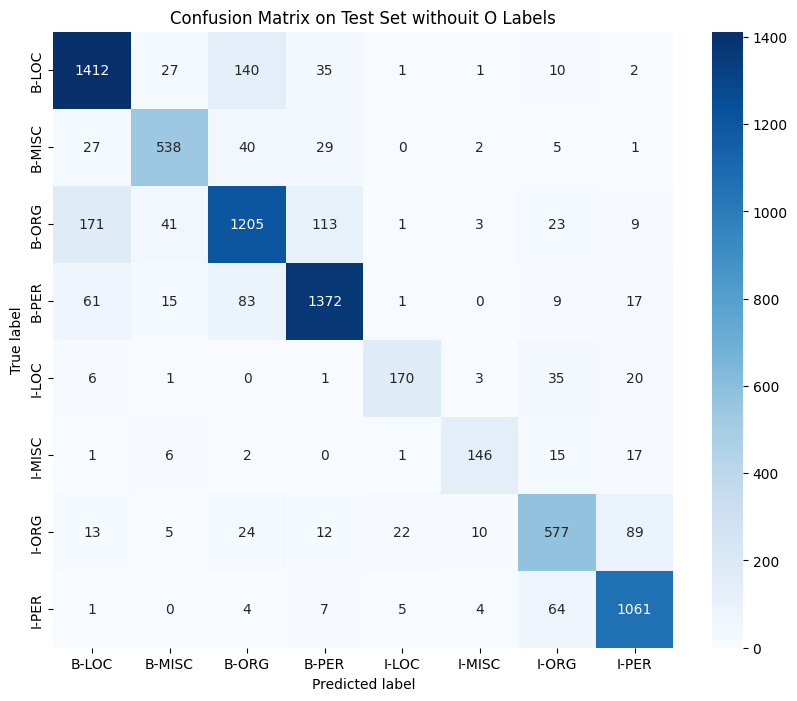

In [44]:
# Filter labels without 'O' class
non_o_labels = [label for label in label_encoder.classes_ if label != 'O']

# Create confusion matrix on test split and convert into dataframe to use in visualization
cm = confusion_matrix(y_test_labels, test_pred_labels, labels=non_o_labels)
cm_df = pd.DataFrame(cm, index=non_o_labels, columns=non_o_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix on Test Set withouit O Labels')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

Focusing on the confusion matrix , I can see that most values are on the diagonal, which means the model correctly predicts many entities. For example, it correctly identifies 1412 times B-LOC, 1205 times B-ORG, 1372 times B-PER ,and 1061 times I-PER . This shows that the model performs reasonably well overall when the patterns are clear.

However, there are some strong confusion patterns. 

One of the biggest is between ORG and LOC. B-ORG is predicted as B-LOC 171 times, and B-LOC is predicted as B-ORG 140 times. This suggests the model struggles to distinguish between organisations and locations, likely because they can share similar words or structures. There is also confusion between ORG and PER. B-ORG is predicted as B-PER 113 times, and B-PER is predicted as B-ORG 83 times. This indicates that the model sometimes cannot clearly separate people from organisations, especially when names look similar.

When looking at inside tags, I can see clear boundary issues. I-ORG is predicted as I-PER 89 times, and I-PER is predicted as I-ORG 64 times. Also, I-LOC is predicted as I-ORG 35 times and I-PER 20 times. These errors show that the model struggles to correctly continue entity spans, not just classify the type.

For MISC, there is also some confusion with other classes, such as B-MISC being predicted as B-ORG 40 times and B-PER 29 times. This is expected because MISC is a broad and less clearly defined category.

Overall, the confusion matrix shows that while the model performs well on clear cases, it struggles with 'similar entity types' and 'multi token boundaries'.

### **8. Most Influential Features Make The Model Predict for Each Entity Class**



A nice advantage of logistic regression is that the model remains interpretable. I can inspect the learned coefficients and see which features push the prediction towards each class.

In [48]:
feature_names = np.array(vectorizer.get_feature_names_out()) # Have features names
class_names = label_encoder.classes_ # Have class names
coef_matrix = log_reg.coef_ # # Keep learned weights

# Define top_features function to find most influential features
def top_features(class_index, top_n=10):

    coefs = coef_matrix[class_index] # weights for one class
    top_ids = np.argsort(coefs)[-top_n:][::-1] # Picks features with highest positive weights

    
    return pd.DataFrame({'feature': feature_names[top_ids],
                         'weight': coefs[top_ids]
                         })

# Display Features and their impact
for class_name in ['B-PER', 'B-ORG', 'B-LOC', 'B-MISC']:
    
    class_index = np.where(class_names == class_name)[0][0]
    print(f'\nTop positive features for {class_name}')
    display(top_features(class_index, top_n=10))


Top positive features for B-PER


,feature,weight
0,-1:word.lower=minister,3.640944
1,-1:word.lower=president,3.237408
2,-1:word.lower=6.,2.093416
3,word.shape=X.,2.091343
4,-1:word.lower=2.,2.069800
5,-1:word.lower=3.,2.065338
6,-1:word.lower=b,1.979115
7,-1:word.lower=general,1.970324
8,-1:word.lower=king,1.767945
9,word[-2:]=ie,1.705597



Top positive features for B-ORG


,feature,weight
0,-1:word.lower=v,3.461555
1,+1:word.lower=yr,2.264846
2,+1:word.lower=ministry,2.156658
3,+1:word.lower=party,2.144378
4,+1:word.lower=v,2.114192
5,word.lower=senate,2.100672
6,+1:word.lower=newsroom,2.026565
7,+1:word.lower=3,2.024565
8,+1:word.lower=times,1.990644
9,+1:word.lower=ptt,1.919745



Top positive features for B-LOC


,feature,weight
0,-1:word.lower=at,3.482811
1,+1:word.lower=1996-08-29,2.483285
2,+1:word.lower=1996-08-26,2.475242
3,+1:word.lower=1996-08-28,2.462268
4,+1:word.lower=netherlands,2.370787
5,+1:word.lower=1996-08-23,2.327579
6,+1:word.lower=kong,2.277321
7,+1:word.lower=house,2.270119
8,+1:word.lower=africa,2.262825
9,+1:word.lower=1996-08-22,2.255462



Top positive features for B-MISC


,feature,weight
0,+1:word.lower=open,3.525517
1,+1:word.lower=cup,3.448235
2,+1:word.lower=league,3.053247
3,+1:word.lower=division,2.555404
4,word[:3]=dem,2.147165
5,+1:word.lower=korean,2.102806
6,word[-3:]=ese,2.057713
7,word[:3]=ser,2.036428
8,-1:word.lower=u.s.,2.006574
9,+1:word.lower=regulation,2.003789


For B-PER, I often see features like 'word.istitle=True' or words like 'john' or 'michael'. This means the model strongly relies on capitalisation and common name patterns. Because of this, it can recognise person names quite well, which explains the high F1 score for PER.

For B-LOC, the model might focus on features like words such as 'london' or 'paris', and also context features like previous words 'in' or 'from'. This shows that the model uses both the word itself and simple context to identify locations, which is why LOC performs reasonably well.

For B-ORG, the features are less consistent. For example, the model might rely on words like 'company', 'bank', or 'group'. However, not all organisation names follow these patterns, so the model cannot generalise as well. This explains why ORG has lower performance.

For B-MISC, the features are usually more mixed and unclear. There are no strong patterns like in PER or LOC, so the model has difficulty learning this class. This is why MISC performance is only moderate.

Overall, this shows that the model depends on simple surface features such as word shape, suffixes, and nearby words. It does not understand deeper meaning, which explains why it struggles with more complex or ambiguous entity types.

In [ ]:
feature_names = np.array(vectorizer.get_feature_names_out()) # Have features names
class_names = label_encoder.classes_ # Have class names
coef_matrix = log_reg.coef_ # # Keep learned weights

# Define top_features function to find most influential features
def top_features(class_index, top_n=10):

    coefs = coef_matrix[class_index] # weights for one class
    top_ids = np.argsort(coefs)[-top_n:][::-1] # Picks features with highest positive weights

    
    return pd.DataFrame({'feature': feature_names[top_ids],
                         'weight': coefs[top_ids]
                         })

# Display Features and their impact
for class_name in ['B-PER', 'B-ORG', 'B-LOC', 'B-MISC']:
    
    class_index = np.where(class_names == class_name)[0][0]
    print(f'\nTop positive features for {class_name}')
    display(top_features(class_index, top_n=10))


Top positive features for B-PER


,feature,weight
0,-1:word.lower=minister,3.640944
1,-1:word.lower=president,3.237408
2,-1:word.lower=6.,2.093416
3,word.shape=X.,2.091343
4,-1:word.lower=2.,2.069800
5,-1:word.lower=3.,2.065338
6,-1:word.lower=b,1.979115
7,-1:word.lower=general,1.970324
8,-1:word.lower=king,1.767945
9,word[-2:]=ie,1.705597



Top positive features for B-ORG


,feature,weight
0,-1:word.lower=v,3.461555
1,+1:word.lower=yr,2.264846
2,+1:word.lower=ministry,2.156658
3,+1:word.lower=party,2.144378
4,+1:word.lower=v,2.114192
5,word.lower=senate,2.100672
6,+1:word.lower=newsroom,2.026565
7,+1:word.lower=3,2.024565
8,+1:word.lower=times,1.990644
9,+1:word.lower=ptt,1.919745



Top positive features for B-LOC


,feature,weight
0,-1:word.lower=at,3.482811
1,+1:word.lower=1996-08-29,2.483285
2,+1:word.lower=1996-08-26,2.475242
3,+1:word.lower=1996-08-28,2.462268
4,+1:word.lower=netherlands,2.370787
5,+1:word.lower=1996-08-23,2.327579
6,+1:word.lower=kong,2.277321
7,+1:word.lower=house,2.270119
8,+1:word.lower=africa,2.262825
9,+1:word.lower=1996-08-22,2.255462



Top positive features for B-MISC


,feature,weight
0,+1:word.lower=open,3.525517
1,+1:word.lower=cup,3.448235
2,+1:word.lower=league,3.053247
3,+1:word.lower=division,2.555404
4,word[:3]=dem,2.147165
5,+1:word.lower=korean,2.102806
6,word[-3:]=ese,2.057713
7,word[:3]=ser,2.036428
8,-1:word.lower=u.s.,2.006574
9,+1:word.lower=regulation,2.003789


### **9. Short Interpretation**

I expect this baseline to perform reasonably well because the CoNLL-2003 dataset contains many visible clues that logistic regression can use, such as capitalisation, common suffixes, POS tags, chunk tags, and short local context.

At the same time, I expect some clear weaknesses. The model classifies each token independently, so it does not capture label dependencies across a sequence. As a result, longer entities and boundary detection may be more difficult. In addition, unseen words and rare entities are likely to reduce performance more compared to a neural sequence model.

Even so, this notebook provides a meaningful and interpretable baseline. If the BiLSTM performs better later, especially on span-level F1, rare entities, or OOV cases, I will be able to explain that improvement against a strong classical reference point.